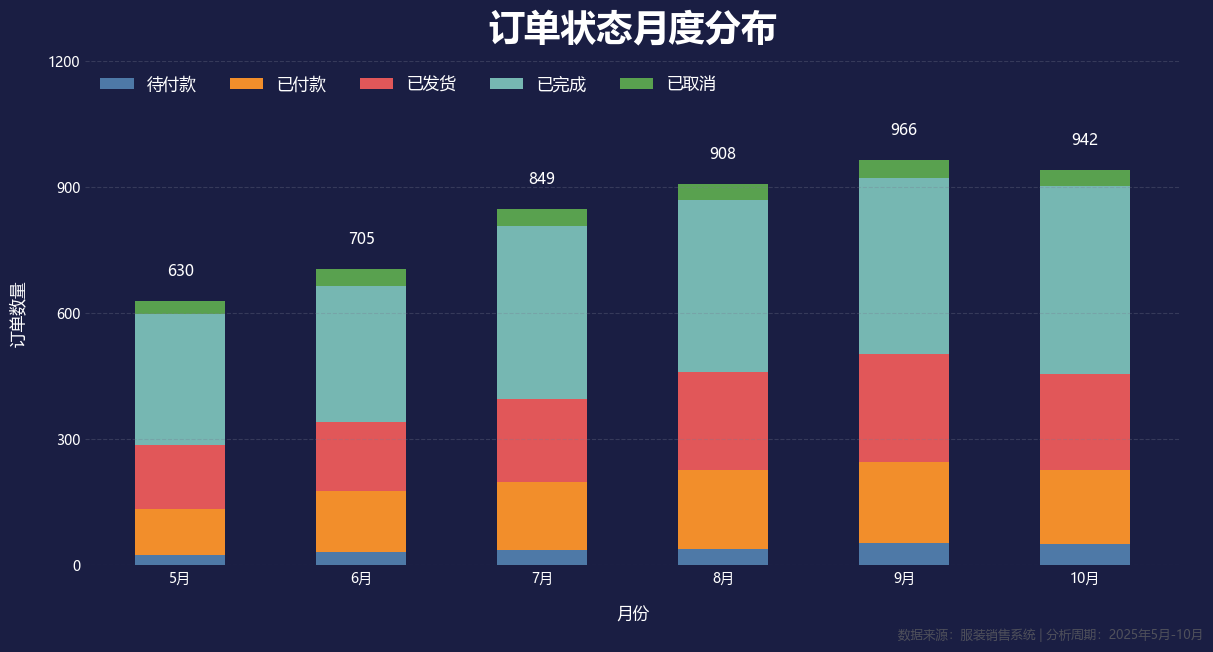

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取订单数据
    df = pd.read_csv("../../数据生成/erp_order.csv", encoding='utf-8-sig', parse_dates=["下单时间"])
    
    # 验证必要字段
    required_columns = ['下单时间', '状态']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺失必要字段: {', '.join(missing_cols)}")
    
    # 检查数据完整性
    if df.empty:
        raise ValueError("订单数据为空")
    if df['状态'].isnull().all():
        raise ValueError("订单状态数据全部为空")
    
    # 数据预处理
    df["月份"] = df["下单时间"].dt.to_period("M").astype(str)
    
    # 计算月度订单数量分布
    month_summary = (
        df.groupby("月份")["状态"]
        .value_counts()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # 确保所有状态列存在
    status_columns = ["待付款", "已付款", "已发货", "已完成", "已取消"]
    for s in status_columns:
        if s not in month_summary.columns:
            month_summary[s] = 0
    
    # 日期排序处理
    month_summary["月份_dt"] = pd.to_datetime(month_summary["月份"])
    month_summary = month_summary.sort_values("月份_dt")
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深色背景
    ax.set_facecolor('#1A1E43')
    
    # 隐藏坐标轴边框
    for spine in ax.spines.values():
        spine.set_visible(False)

    # 绘制堆叠柱状图
    colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]

    bottom = np.zeros(len(month_summary))
    for i, col in enumerate(status_columns):
        ax.bar(month_summary["月份"], month_summary[col], bottom=bottom, label=col, color=colors[i], width=0.5)
        bottom += month_summary[col]
        
    # 添加每组总数标签
    for i, total in enumerate(bottom):
        ax.text(i, total + 50, str(int(total)), ha='center', va='bottom', fontsize=11, color='white')

    # 设置 y 轴标签每隔 300 一格
    ax.set_yticks(np.arange(0, bottom.max() + 300, 300))

    # 添加标题和标签
    plt.title("订单状态月度分布", fontsize=26, fontweight="bold", color="#ffffff", pad=16)
    plt.xlabel("月份", fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel("订单数量", fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加数据来源说明
    plt.figtext(0.88, 0.03, '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
                ha='center', fontsize=9, color='#666666', alpha=0.7)    
    
    # 添加图例
    ax.legend(frameon=False, fontsize=12, loc="upper left", bbox_to_anchor=(0, 1), ncol=len(status_columns), labelcolor='white')
    
    # 配置X轴，显示月份标签
    ticks = list(range(len(month_summary["月份"])))
    labels = [f"{int(m.split('-')[1])}月" for m in month_summary["月份"]]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    # 隐藏刻度线
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', length=0)
    ax.xaxis.set_tick_params(colors='#ffffff')
    ax.yaxis.set_tick_params(colors='#ffffff')
    
    # 添加网格线
    ax.grid(axis='y', linestyle="--", alpha=0.3, color='#777b92')
    ax.grid(axis='x', visible=False)
    
    # 调整布局
    plt.tight_layout(rect=(0, 0.03, 1, 0.95))
    
    # 保存图表
    plt.savefig(
        "订单状态月度分布.png",
        dpi=300,
        bbox_inches='tight',
        facecolor=fig.get_facecolor()
    )
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **待付款**（浅蓝色）：
  - 5月：数量较少，表明月初订单创建量较低。
  - 6月至10月：数量逐渐增加，显示出订单创建量的增长趋势。

- **已付款**（橙色）：
  - 5月至10月：数量相对稳定，表明付款订单量在各月间变化不大。

- **已发货**（红色）：
  - 5月至10月：数量逐渐增加，尤其在9月和10月，显示出发货量的增长。

- **已完成**（青色）：
  - 5月至10月：数量持续增加，尤其在9月和10月，表明订单完成量的增长。

- **已取消**（绿色）：
  - 5月至10月：数量相对较少，但在10月略有增加，可能与订单取消政策或市场需求变化有关。


# 结论

从订单状态月度分布来看，已完成订单数量持续增长，显示出较高的订单履行效率。已发货订单数量的增加可能反映了库存管理和物流效率的提升。待付款订单的增长趋势可能指示了订单创建量的上升，而已取消订单数量的增加可能需要进一步分析原因。